# Combined-basis memory experiments

The previous notebook prepared and measured one logical basis at a time.
A combined-basis experiment instead entangles each logical qubit with a noiseless reference qubit, so one circuit can detect flips in both X- and Z-type logical observables.

The reference qubits are an analysis device, not physical fault-tolerant hardware.
Sinter reports whether a shot has any tracked logical-observable failure; it does not return a separate rate for every observable.


## Setup

Install the dependencies once in the environment that will run the notebook:

```bash
python -m pip install qldpc matplotlib
```


In [1]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
from sympy.abc import x, y

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Split the CSS detector graph

The combined circuit contains X- and Z-sector detectors.
`SubgraphDecoder` decodes those sectors independently, then combines their observable predictions.
The detector and observable sets below make that ownership explicit.


In [2]:
def code_label(code):
    known_distance = code.get_distance_if_known()
    suffix = f", {known_distance}" if known_distance is not None else ""
    return f"[[{len(code)}, {code.dimension}{suffix}]]"


def run_combined_memory_experiments(
    codes_and_rounds: Sequence[tuple[codes.CSSCode, int]],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-3, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
    **decoder_kwargs,
):
    tasks = []
    custom_decoders = {}

    for code_index, (code, num_rounds) in enumerate(codes_and_rounds):
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
        )
        detectors_x = parts.detector_record.get_events(*parts.qubit_ids.checks_x)
        detectors_z = parts.detector_record.get_events(*parts.qubit_ids.checks_z)
        observables_x = range(code.dimension)
        observables_z = range(code.dimension, 2 * code.dimension)

        decoder_name = f"css_{code_index}"
        custom_decoders[decoder_name] = decoders.SubgraphDecoder(
            (detectors_x, detectors_z),
            (observables_x, observables_z),
            **decoder_kwargs,
        )

        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            noisy_cycle = noise.noisy_circuit(parts.qec_cycle)
            tasks.append(
                sinter.Task(
                    circuit=parts.initialization + noisy_cycle + parts.readout,
                    decoder=decoder_name,
                    json_metadata={
                        "label": code_label(code),
                        "probability": probability,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def plot_combined_results(codes_and_rounds, **decoder_kwargs):
    stats = run_combined_memory_experiments(codes_and_rounds, **decoder_kwargs)
    figure, axis = plt.subplots(figsize=(5.5, 4.2))
    markers = ("o", "s", "^", "D")
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["probability"],
        group_func=lambda stat: stat.json_metadata["label"],
        plot_args_func=lambda index, _curve_id: {
            "marker": markers[index % len(markers)],
        },
    )
    reference_rates = sorted({stat.json_metadata["probability"] for stat in stats})
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlabel("physical error rate per operation")
    axis.set_ylabel("estimated probability of a logical-observable failure")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Surface codes

The built-in distances are exact, so the supplied number of rounds is not an estimate.
MWPM is used inside each CSS sector.


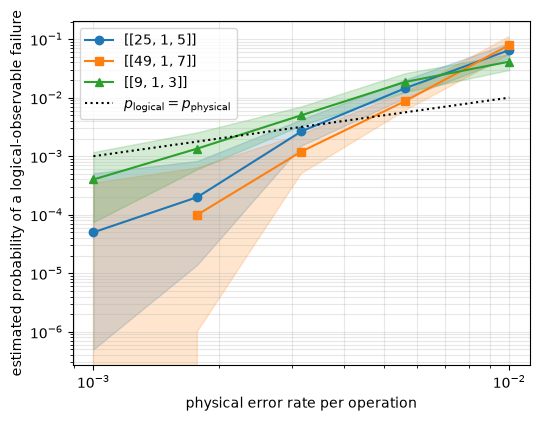

In [3]:
surface_codes = [(codes.SurfaceCode(distance, rotated=True), distance) for distance in (3, 5, 7)]
plot_combined_results(surface_codes, with_MWPM=True)
plt.show()

## Toric codes

The same sector split works with BP+LSD.
Only the decoder configuration changes.


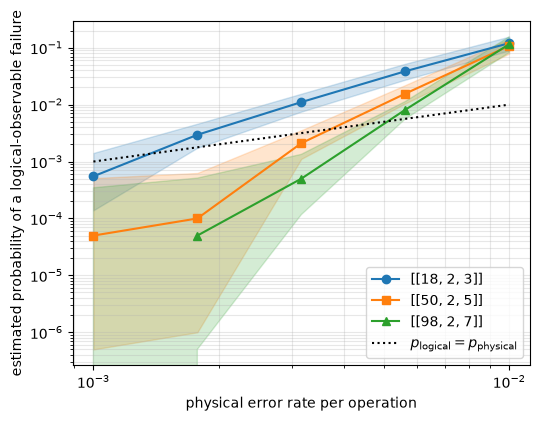

In [4]:
toric_codes = [(codes.ToricCode(distance, rotated=False), distance) for distance in (3, 5, 7)]
plot_combined_results(
    toric_codes,
    with_BP_LSD=True,
    max_iter=30,
    bp_method="ms",
    lsd_method="lsd_cs",
    lsd_order=0,
)
plt.show()

## A bivariate bicycle code

The $[[72,12,6]]$ value below comes from the cited construction in arXiv:2308.07915; this notebook does not recompute the distance.
We supply six rounds explicitly and use BP+LSD.
The result is a small workflow check, not a reproduction of the paper's benchmark, which used different decoding and reported a different observable aggregation.


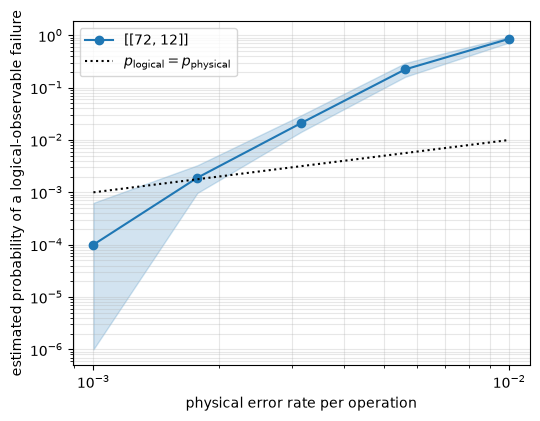

In [5]:
bb72 = codes.BBCode(
    {x: 6, y: 6},
    x**3 + y + y**2,
    y**3 + x + x**2,
)
plot_combined_results(
    [(bb72, 6)],
    with_BP_LSD=True,
    max_iter=30,
    bp_method="ms",
    lsd_method="lsd_cs",
    lsd_order=0,
)
plt.show()

All three sections estimate the chance that at least one tracked logical observable is predicted incorrectly.
Changing the observable aggregation, decoder, circuit, or stopping rule changes the quantity being compared.
